In [1]:
# import multiprocessing
# multiprocessing.set_start_method("fork", force=True)

In [2]:
#System dependencies
!apt-get install -y xvfb ffmpeg -q
!pip install highway-env stable-baselines3 gymnasium pyvirtualdisplay imageio -q

Reading package lists...
Building dependency tree...
Reading state information...
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
xvfb is already the newest version (2:21.1.4-2ubuntu1.7~22.04.16).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.7/107.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 34.4 MB/s eta 0:00:00


In [3]:
import os
import re
import gymnasium as gym
import highway_env
import numpy as np
import imageio
import matplotlib.pyplot as plt
from IPython.display import Image, display
from stable_baselines3 import A2C
from stable_baselines3.common.vec_env import SubprocVecEnv, VecMonitor, DummyVecEnv
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import CheckpointCallback, BaseCallback
from google.colab import drive

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [4]:
from pyvirtualdisplay import Display
vdisplay = Display(visible=False, size=(600, 150))
vdisplay.start()
print("Display alive:", vdisplay.is_alive())


Display alive: True


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [5]:
from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = "/content/drive/MyDrive/AVERT/"
import os
os.makedirs(SAVE_DIR, exist_ok=True)

Mounted at /content/drive


In [6]:
# ── Cell 4: PursuerVehicle ───────────────────────────────────────
import highway_env.vehicle.behavior as behavior
from highway_env.vehicle.behavior import IDMVehicle

class PursuerVehicle(IDMVehicle):
    PURSUIT_GAIN = 1.5
    def act(self, action=None):
        ego = self.road.vehicles[0]
        if self.lane_index[2] < ego.lane_index[2]:
            action = "LANE_RIGHT"
        elif self.lane_index[2] > ego.lane_index[2]:
            action = "LANE_LEFT"
        else:
            action = "FASTER"
        super().act(action)

behavior.PursuerVehicle = PursuerVehicle
print("PursuerVehicle registered")


PursuerVehicle registered


In [16]:
# ── Cell 5: Configs ──────────────────────────────────────────────
stage1_config = {
    "observation": {"type": "Kinematics"},
    "action": {"type": "DiscreteMetaAction"},
    "lanes_count": 4,
    "vehicles_count": 15,
    "duration": 15,
    "simulation_frequency":5,
    "policy_frequency": 1,
    "other_vehicles_type": "highway_env.vehicle.behavior.IDMVehicle",
    "collision_reward": -2,
    "high_speed_reward": 0.4,
    "right_lane_reward": 0.1,
    "lane_change_reward": 0.0,
    "reward_speed_range": [20, 30],
    "normalize_reward": True,
}

stage2_config = {
    **stage1_config,
    "vehicles_count": 20,
    "other_vehicles_type": "highway_env.vehicle.behavior.AggressiveVehicle",
    "collision_reward": -3,
}

stage3_config = {
    **stage1_config,
    "vehicles_count": 25,
    "other_vehicles_type": "highway_env.vehicle.behavior.PursuerVehicle",
    "collision_reward": -5,
}

roundabout_config = {
    "observation": {"type": "Kinematics"},
    "action": {"type": "DiscreteMetaAction"},
    "collision_reward": -3,
    "high_speed_reward": 0.4,
    "normalize_reward": True,
}

merge_config = {
    "observation": {"type": "Kinematics"},
    "action": {"type": "DiscreteMetaAction"},
    "collision_reward": -3,
    "high_speed_reward": 0.4,
    "normalize_reward": True,
}

In [17]:
# ── Cell 6: Env factories ────────────────────────────────────────
def make_stage1_env():
    try:
        env = gym.make("highway-v0")
        env.unwrapped.configure(stage1_config)
        return env
    except Exception as e:
        print(f"[Worker] env creation failed: {e}")
        raise


def make_stage2_env():
    env = gym.make("highway-v0")
    env.unwrapped.configure(stage2_config)
    return env

def make_stage3_env():
    # Re-register inside the worker
    import highway_env.vehicle.behavior as behavior
    from highway_env.vehicle.behavior import IDMVehicle

    class PursuerVehicle(IDMVehicle):
        PURSUIT_GAIN = 1.5
        def act(self, action=None):
            ego = self.road.vehicles[0]
            if self.lane_index[2] < ego.lane_index[2]:
                action = "LANE_RIGHT"
            elif self.lane_index[2] > ego.lane_index[2]:
                action = "LANE_LEFT"
            else:
                action = "FASTER"
            super().act(action)

    behavior.PursuerVehicle = PursuerVehicle

    env = gym.make("highway-v0")
    env.unwrapped.configure(stage3_config)
    return env

def make_roundabout_env():
    env = gym.make("roundabout-v0")
    env.unwrapped.configure(roundabout_config)
    return env

def make_merge_env():
    env = gym.make("merge-v0")
    env.unwrapped.configure(merge_config)
    return env

print("Env factories ready")

Env factories ready


In [18]:
# ── Cell 7: Logger ───────────────────────────────────────────────
class RewardLogger(BaseCallback):
    def __init__(self):
        super().__init__()
        self.rewards = []

    def _on_step(self):
        for info in self.locals.get("infos", []):
            if "episode" in info:
                self.rewards.append(info["episode"]["r"])
        return True

In [19]:
# # ── Cell 8: Train function ───────────────────────────────────────
# N_ENVS = 8

# def train_stage(make_env_fn, stage_name, timesteps=10_000, model=None):
#     vec_env = make_vec_env(make_env_fn, n_envs=N_ENVS, vec_env_cls=DummyVecEnv)
#     vec_env = VecMonitor(vec_env)

#     logger = RewardLogger()
#     checkpoint_cb = CheckpointCallback(
#         save_freq=max(1000 // N_ENVS, 1),
#         save_path=f"{SAVE_DIR}{stage_name}_checkpoints/",
#         name_prefix=f"avert_{stage_name}",
#     )

#     if model is None:
#         model = A2C(
#             "MlpPolicy",
#             vec_env,
#             verbose=2,
#             device="cpu",
#             learning_rate=7e-4,
#             n_steps=32,
#             gamma=0.99,
#             ent_coef=0.01,
#             vf_coef=0.5,
#             max_grad_norm=0.5,
#         )
#     else:
#         model.set_env(vec_env)

#     model.learn(
#         total_timesteps=timesteps,
#         callback=[checkpoint_cb, logger],
#         reset_num_timesteps=False,
#     )
#     model.save(f"{SAVE_DIR}avert_{stage_name}_final")
#     print(f"{stage_name} complete — saved")
#     vec_env.close()
#     return model, logger


In [20]:
from stable_baselines3.common.monitor import Monitor

In [21]:
def train_stage(make_env_fn, stage_name, timesteps=10_000, model=None):
    env = make_env_fn()
    env = Monitor(env)

    logger = RewardLogger()

    if model is None:
        model = A2C(
            "MlpPolicy",
            env,
            verbose=1,
            device="cpu",
            learning_rate=7e-4,
            n_steps=8,
            gamma=0.99,
            ent_coef=0.01,
            vf_coef=0.5,
            max_grad_norm=0.5,
        )
    else:
        model.set_env(env)

    model.learn(
        total_timesteps=timesteps,
        callback=[logger],
        reset_num_timesteps=False,
    )
    model.save(f"{SAVE_DIR}avert_{stage_name}_final")
    print(f"{stage_name} complete — saved")
    env.close()
    return model, logger

In [22]:
import os
os.environ["SDL_VIDEODRIVER"] = "dummy"
os.environ["SDL_AUDIODRIVER"] = "dummy"

In [23]:
# # ── Sanity check: can we even make one env? ──
# env = make_stage1_env()
# obs, info = env.reset()
# print("obs shape:", obs.shape)
# obs, reward, term, trunc, info = env.step(env.action_space.sample())
# print("step reward:", reward)
# env.close()
# print("Single env OK")

In [24]:
# ── Cell 9: CURRICULUM (30k total) ──────────────────────────────
print("=== STAGE 1: Passive Traffic ===")
model_curr, logger1 = train_stage(make_stage1_env, "stage1", timesteps=5_000)


=== STAGE 1: Passive Traffic ===
Using cpu device
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

------------------------------------
| rollout/              |          |
|    ep_len_mean        | 12.6     |
|    ep_rew_mean        | 10.3     |
| time/                 |          |
|    fps                | 22       |
|    iterations         | 100      |
|    time_elapsed       | 35       |
|    total_timesteps    | 800      |
| train/                |          |
|    entropy_loss       | -1.36    |
|    explained_variance | 0.00141  |
|    learning_rate      | 0.0007   |
|    n_updates          | 99       |
|    policy_loss        | 3.39     |
|    value_loss         | 7.97     |
------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


------------------------------------
| rollout/              |          |
|    ep_len_mean        | 13.5     |
|    ep_rew_mean        | 11.2     |
| time/                 |          |
|    fps                | 22       |
|    iterations         | 200      |
|    time_elapsed       | 71       |
|    total_timesteps    | 1600     |
| train/                |          |
|    entropy_loss       | -1       |
|    explained_variance | -0.00567 |
|    learning_rate      | 0.0007   |
|    n_updates          | 199      |
|    policy_loss        | 2.25     |
|    value_loss         | 10.7     |
------------------------------------


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

-------------------------------------
| rollout/              |           |
|    ep_len_mean        | 14.7      |
|    ep_rew_mean        | 12.1      |
| time/                 |           |
|    fps                | 22        |
|    iterations         | 600       |
|    time_elapsed       | 215       |
|    total_timesteps    | 4800      |
| train/                |           |
|    entropy_loss       | -0.857    |
|    explained_variance | -0.000554 |
|    learning_rate      | 0.0007    |
|    n_updates          | 599       |
|    policy_loss        | 2.68      |
|    value_loss         | 5.29      |
-------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

stage1 complete — saved


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [25]:

print("\n=== STAGE 2: Aggressive Traffic ===")
model_curr, logger2 = train_stage(make_stage2_env, "stage2", timesteps=5_000, model=model_curr)



=== STAGE 2: Aggressive Traffic ===
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

------------------------------------
| rollout/              |          |
|    ep_len_mean        | 14.7     |
|    ep_rew_mean        | 12.5     |
| time/                 |          |
|    fps                | 14       |
|    iterations         | 100      |
|    time_elapsed       | 55       |
|    total_timesteps    | 5800     |
| train/                |          |
|    entropy_loss       | -0.854   |
|    explained_variance | 0.000134 |
|    learning_rate      | 0.0007   |
|    n_updates          | 724      |
|    policy_loss        | 1.16     |
|    value_loss         | 4.15     |
------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

-------------------------------------
| rollout/              |           |
|    ep_len_mean        | 14.5      |
|    ep_rew_mean        | 12.6      |
| time/                 |           |
|    fps                | 14        |
|    iterations         | 200       |
|    time_elapsed       | 109       |
|    total_timesteps    | 6600      |
| train/                |           |
|    entropy_loss       | -0.814    |
|    explained_variance | -0.000234 |
|    learning_rate      | 0.0007    |
|    n_updates          | 824       |
|    policy_loss        | 1.42      |
|    value_loss         | 4.92      |
-------------------------------------


...

------------------------------------
| rollout/              |          |
|    ep_len_mean        | 14.4     |
|    ep_rew_mean        | 12.6     |
| time/                 |          |
|    fps                | 14       |
|    iterations         | 500      |
|    time_elapsed       | 275      |
|    total_timesteps    | 9000     |
| train/                |          |
|    entropy_loss       | -0.576   |
|    explained_variance | 0.000127 |
|    learning_rate      | 0.0007   |
|    n_updates          | 1124     |
|    policy_loss        | 0.312    |
|    value_loss         | 2.54     |
------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

-------------------------------------
| rollout/              |           |
|    ep_len_mean        | 14.5      |
|    ep_rew_mean        | 12.6      |
| time/                 |           |
|    fps                | 14        |
|    iterations         | 600       |
|    time_elapsed       | 329       |
|    total_timesteps    | 9800      |
| train/                |           |
|    entropy_loss       | -0.626    |
|    explained_variance | -4.65e-06 |
|    learning_rate      | 0.0007    |
|    n_updates          | 1224      |
|    policy_loss        | 0.869     |
|    value_loss         | 1.78      |
-------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

stage2 complete — saved


In [26]:

print("\n=== STAGE 3: Active Pursuers ===")
model_curr, logger3 = train_stage(make_stage3_env, "stage3", timesteps=5_000, model=model_curr)



=== STAGE 3: Active Pursuers ===
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

-------------------------------------
| rollout/              |           |
|    ep_len_mean        | 14.4      |
|    ep_rew_mean        | 12.9      |
| time/                 |           |
|    fps                | 12        |
|    iterations         | 100       |
|    time_elapsed       | 65        |
|    total_timesteps    | 10800     |
| train/                |           |
|    entropy_loss       | -0.634    |
|    explained_variance | -1.82e-05 |
|    learning_rate      | 0.0007    |
|    n_updates          | 1349      |
|    policy_loss        | 0.603     |
|    value_loss         | 0.538     |
-------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

------------------------------------
| rollout/              |          |
|    ep_len_mean        | 14.9     |
|    ep_rew_mean        | 13.7     |
| time/                 |          |
|    fps                | 12       |
|    iterations         | 200      |
|    time_elapsed       | 129      |
|    total_timesteps    | 11600    |
| train/                |          |
|    entropy_loss       | -0.756   |
|    explained_variance | 6.05e-05 |
|    learning_rate      | 0.0007   |
|    n_updates          | 1449     |
|    policy_loss        | 0.795    |
|    value_loss         | 1.2      |
------------------------------------


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


------------------------------------
| rollout/              |          |
|    ep_len_mean        | 14.9     |
|    ep_rew_mean        | 13.7     |
| time/                 |          |
|    fps                | 12       |
|    iterations         | 600      |
|    time_elapsed       | 387      |
|    total_timesteps    | 14800    |
| train/                |          |
|    entropy_loss       | -0.821   |
|    explained_variance | 0.000104 |
|    learning_rate      | 0.0007   |
|    n_updates          | 1849     |
|    policy_loss        | 0.211    |
|    value_loss         | 0.0234   |
------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

stage3 complete — saved


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [27]:

# ── Cell 10: SCRATCH BASELINE (30k, same budget) ────────────────
print("=== SCRATCH BASELINE: Stage 3 ===")
model_scratch, logger_scratch = train_stage(make_stage3_env, "stage3_scratch", timesteps=15_000)


=== SCRATCH BASELINE: Stage 3 ===
Using cpu device
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

------------------------------------
| rollout/              |          |
|    ep_len_mean        | 13.8     |
|    ep_rew_mean        | 12.6     |
| time/                 |          |
|    fps                | 12       |
|    iterations         | 100      |
|    time_elapsed       | 63       |
|    total_timesteps    | 800      |
| train/                |          |
|    entropy_loss       | -0.943   |
|    explained_variance | -0.00453 |
|    learning_rate      | 0.0007   |
|    n_updates          | 99       |
|    policy_loss        | 3.36     |
|    value_loss         | 14.9     |
------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


------------------------------------
| rollout/              |          |
|    ep_len_mean        | 14.5     |
|    ep_rew_mean        | 13.3     |
| time/                 |          |
|    fps                | 12       |
|    iterations         | 200      |
|    time_elapsed       | 125      |
|    total_timesteps    | 1600     |
| train/                |          |
|    entropy_loss       | -0.721   |
|    explained_variance | 0.000205 |
|    learning_rate      | 0.0007   |
|    n_updates          | 199      |
|    policy_loss        | 0.698    |
|    value_loss         | 12.9     |
------------------------------------


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

------------------------------------
| rollout/              |          |
|    ep_len_mean        | 15       |
|    ep_rew_mean        | 13.8     |
| time/                 |          |
|    fps                | 12       |
|    iterations         | 1800     |
|    time_elapsed       | 1182     |
|    total_timesteps    | 14400    |
| train/                |          |
|    entropy_loss       | -0.744   |
|    explained_variance | 2.38e-07 |
|    learning_rate      | 0.0007   |
|    n_updates          | 1799     |
|    policy_loss        | 0.00493  |
|    value_loss         | 0.000173 |
------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

stage3_scratch complete — saved


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [28]:

# ── Cell 11: TRANSFER from curriculum ───────────────────────────
# Load fresh copy each time so we don't mutate model_curr
print("=== TRANSFER: Roundabout ===")
model_round_trans = A2C.load(f"{SAVE_DIR}avert_stage3_final")
model_round_trans, logger_round_trans = train_stage(
    make_roundabout_env, "round_transfer", timesteps=5_000, model=model_round_trans
)


=== TRANSFER: Roundabout ===
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

------------------------------------
| rollout/              |          |
|    ep_len_mean        | 8.3      |
|    ep_rew_mean        | 6.95     |
| time/                 |          |
|    fps                | 16       |
|    iterations         | 100      |
|    time_elapsed       | 48       |
|    total_timesteps    | 15800    |
| train/                |          |
|    entropy_loss       | -0.925   |
|    explained_variance | -0.0137  |
|    learning_rate      | 0.0007   |
|    n_updates          | 1974     |
|    policy_loss        | -0.325   |
|    value_loss         | 5.72     |
------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

------------------------------------
| rollout/              |          |
|    ep_len_mean        | 8.13     |
|    ep_rew_mean        | 6.77     |
| time/                 |          |
|    fps                | 16       |
|    iterations         | 200      |
|    time_elapsed       | 99       |
|    total_timesteps    | 16600    |
| train/                |          |
|    entropy_loss       | -1.07    |
|    explained_variance | 0.0306   |
|    learning_rate      | 0.0007   |
|    n_updates          | 2074     |
|    policy_loss        | -11.3    |
|    value_loss         | 1.67e+03 |
------------------------------------


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

------------------------------------
| rollout/              |          |
|    ep_len_mean        | 7.94     |
|    ep_rew_mean        | 6.5      |
| time/                 |          |
|    fps                | 15       |
|    iterations         | 600      |
|    time_elapsed       | 300      |
|    total_timesteps    | 19800    |
| train/                |          |
|    entropy_loss       | -1.29    |
|    explained_variance | 0.356    |
|    learning_rate      | 0.0007   |
|    n_updates          | 2474     |
|    policy_loss        | -105     |
|    value_loss         | 6.87e+03 |
------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

round_transfer complete — saved


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [29]:

print("\n=== TRANSFER: Merge ===")
model_merge_trans = A2C.load(f"{SAVE_DIR}avert_stage3_final")
model_merge_trans, logger_merge_trans = train_stage(
    make_merge_env, "merge_transfer", timesteps=5_000, model=model_merge_trans
)


=== TRANSFER: Merge ===
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

------------------------------------
| rollout/              |          |
|    ep_len_mean        | 14.4     |
|    ep_rew_mean        | 12.9     |
| time/                 |          |
|    fps                | 28       |
|    iterations         | 100      |
|    time_elapsed       | 28       |
|    total_timesteps    | 15800    |
| train/                |          |
|    entropy_loss       | -0.982   |
|    explained_variance | 0.000338 |
|    learning_rate      | 0.0007   |
|    n_updates          | 1974     |
|    policy_loss        | -79.7    |
|    value_loss         | 6.99e+03 |
------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

------------------------------------
| rollout/              |          |
|    ep_len_mean        | 14.2     |
|    ep_rew_mean        | 12.5     |
| time/                 |          |
|    fps                | 28       |
|    iterations         | 200      |
|    time_elapsed       | 56       |
|    total_timesteps    | 16600    |
| train/                |          |
|    entropy_loss       | -0.834   |
|    explained_variance | 0.000554 |
|    learning_rate      | 0.0007   |
|    n_updates          | 2074     |
|    policy_loss        | 0.0956   |
|    value_loss         | 0.0407   |
------------------------------------


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


------------------------------------
| rollout/              |          |
|    ep_len_mean        | 15.3     |
|    ep_rew_mean        | 13.4     |
| time/                 |          |
|    fps                | 28       |
|    iterations         | 600      |
|    time_elapsed       | 170      |
|    total_timesteps    | 19800    |
| train/                |          |
|    entropy_loss       | -0.823   |
|    explained_variance | 0.0184   |
|    learning_rate      | 0.0007   |
|    n_updates          | 2474     |
|    policy_loss        | 0.358    |
|    value_loss         | 4.1      |
------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

merge_transfer complete — saved


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [30]:


# ── Cell 12: TRANSFER SCRATCH BASELINES ─────────────────────────
print("=== SCRATCH BASELINE: Roundabout ===")
_, logger_round_scratch = train_stage(make_roundabout_env, "round_scratch", timesteps=5_000)


=== SCRATCH BASELINE: Roundabout ===
Using cpu device
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

------------------------------------
| rollout/              |          |
|    ep_len_mean        | 7.73     |
|    ep_rew_mean        | 6.06     |
| time/                 |          |
|    fps                | 15       |
|    iterations         | 100      |
|    time_elapsed       | 50       |
|    total_timesteps    | 800      |
| train/                |          |
|    entropy_loss       | -1.58    |
|    explained_variance | -0.0188  |
|    learning_rate      | 0.0007   |
|    n_updates          | 99       |
|    policy_loss        | -5.59    |
|    value_loss         | 26.2     |
------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


------------------------------------
| rollout/              |          |
|    ep_len_mean        | 8.11     |
|    ep_rew_mean        | 6.45     |
| time/                 |          |
|    fps                | 16       |
|    iterations         | 200      |
|    time_elapsed       | 97       |
|    total_timesteps    | 1600     |
| train/                |          |
|    entropy_loss       | -1.59    |
|    explained_variance | 0.00917  |
|    learning_rate      | 0.0007   |
|    n_updates          | 199      |
|    policy_loss        | -4.13    |
|    value_loss         | 46.3     |
------------------------------------


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

------------------------------------
| rollout/              |          |
|    ep_len_mean        | 7.74     |
|    ep_rew_mean        | 6.12     |
| time/                 |          |
|    fps                | 16       |
|    iterations         | 600      |
|    time_elapsed       | 298      |
|    total_timesteps    | 4800     |
| train/                |          |
|    entropy_loss       | -1.59    |
|    explained_variance | 0.0444   |
|    learning_rate      | 0.0007   |
|    n_updates          | 599      |
|    policy_loss        | 2.34     |
|    value_loss         | 3.54     |
------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


round_scratch complete — saved


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [31]:

print("\n=== SCRATCH BASELINE: Merge ===")
_, logger_merge_scratch = train_stage(make_merge_env, "merge_scratch", timesteps=5_000)



=== SCRATCH BASELINE: Merge ===
Using cpu device
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


------------------------------------
| rollout/              |          |
|    ep_len_mean        | 13.2     |
|    ep_rew_mean        | 11.6     |
| time/                 |          |
|    fps                | 29       |
|    iterations         | 100      |
|    time_elapsed       | 27       |
|    total_timesteps    | 800      |
| train/                |          |
|    entropy_loss       | -1.23    |
|    explained_variance | 0.504    |
|    learning_rate      | 0.0007   |
|    n_updates          | 99       |
|    policy_loss        | 3.58     |
|    value_loss         | 6.77     |
------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

------------------------------------
| rollout/              |          |
|    ep_len_mean        | 13.4     |
|    ep_rew_mean        | 11.7     |
| time/                 |          |
|    fps                | 29       |
|    iterations         | 200      |
|    time_elapsed       | 55       |
|    total_timesteps    | 1600     |
| train/                |          |
|    entropy_loss       | -1.15    |
|    explained_variance | 0.699    |
|    learning_rate      | 0.0007   |
|    n_updates          | 199      |
|    policy_loss        | -3.09    |
|    value_loss         | 7.25     |
------------------------------------


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

------------------------------------
| rollout/              |          |
|    ep_len_mean        | 16.2     |
|    ep_rew_mean        | 14.1     |
| time/                 |          |
|    fps                | 28       |
|    iterations         | 600      |
|    time_elapsed       | 167      |
|    total_timesteps    | 4800     |
| train/                |          |
|    entropy_loss       | -0.266   |
|    explained_variance | 0.863    |
|    learning_rate      | 0.0007   |
|    n_updates          | 599      |
|    policy_loss        | 0.723    |
|    value_loss         | 2.64     |
------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

merge_scratch complete — saved


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [32]:
# ── Cell 13: PLOTS ───────────────────────────────────────────────
def plot_rewards(stage_rewards):
    plt.figure(figsize=(12, 4))
    colors = {"Stage 1": "steelblue", "Stage 2": "darkorange", "Stage 3": "crimson"}
    offset = 0
    for stage, rewards in stage_rewards.items():
        x = range(offset, offset + len(rewards))
        plt.plot(x, rewards, label=stage, color=colors[stage], alpha=0.6)
        plt.axvline(x=offset, linestyle="--", color=colors[stage], alpha=0.3)
        offset += len(rewards)
    plt.xlabel("Episode")
    plt.ylabel("Episode Reward")
    plt.title("AVERT: Curriculum Training Reward Curves")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}avert_reward_curves.png", dpi=150)
    plt.show()

def plot_comparison(curriculum_rewards, scratch_rewards):
    plt.figure(figsize=(10, 4))
    plt.plot(curriculum_rewards, label="Curriculum (30k total)", color="steelblue", alpha=0.7)
    plt.plot(scratch_rewards, label="Scratch (30k on Stage 3)", color="crimson", alpha=0.7)
    plt.xlabel("Episode")
    plt.ylabel("Episode Reward")
    plt.title("AVERT — Curriculum vs Scratch on Stage 3 (Equal Compute)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}avert_comparison.png", dpi=150)
    plt.show()

def plot_transfer_vs_scratch(transfer_rewards, scratch_rewards, env_name, c_transfer, c_scratch):
    plt.figure(figsize=(10, 4))
    plt.plot(transfer_rewards, label=f"{env_name} Transfer", color=c_transfer, alpha=0.7)
    plt.plot(scratch_rewards, label=f"{env_name} Scratch", color=c_scratch, alpha=0.7)
    plt.xlabel("Episode")
    plt.ylabel("Episode Reward")
    plt.title(f"AVERT — Transfer vs Scratch: {env_name}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}avert_{env_name.lower()}_transfer_vs_scratch.png", dpi=150)
    plt.show()
    n = 20
    print(f"{env_name} last-{n} mean — Transfer: {np.mean(transfer_rewards[-n:]):.2f} | "
          f"Scratch: {np.mean(scratch_rewards[-n:]):.2f}")


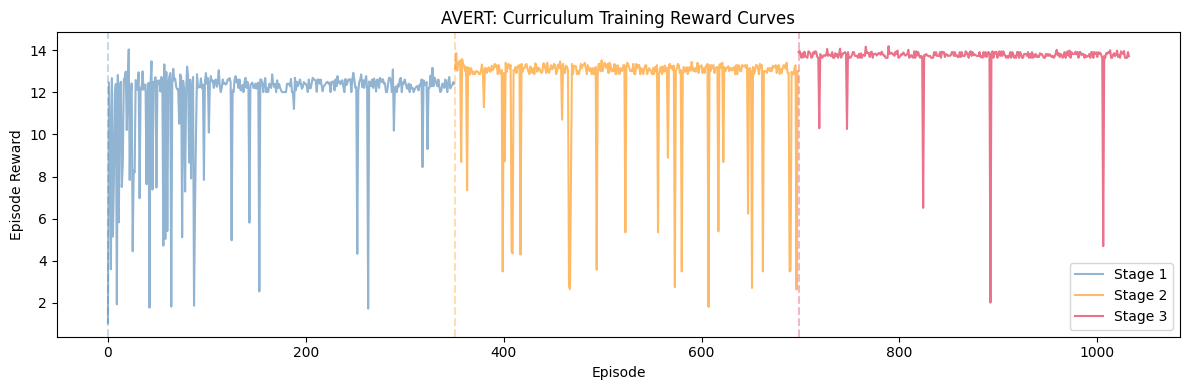

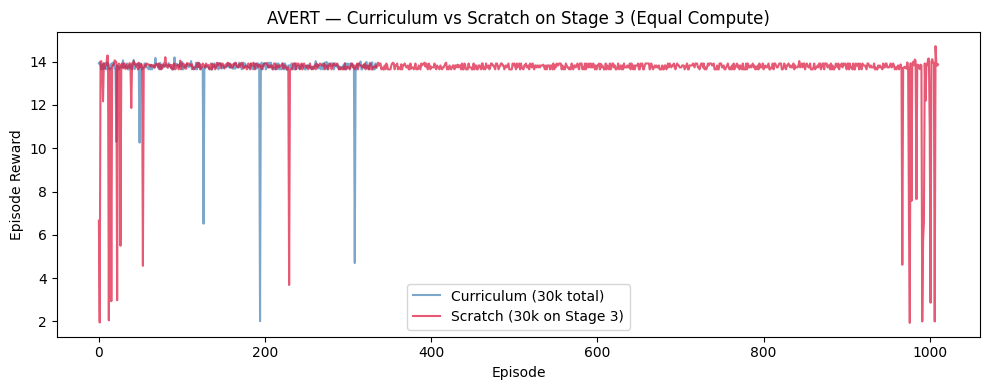

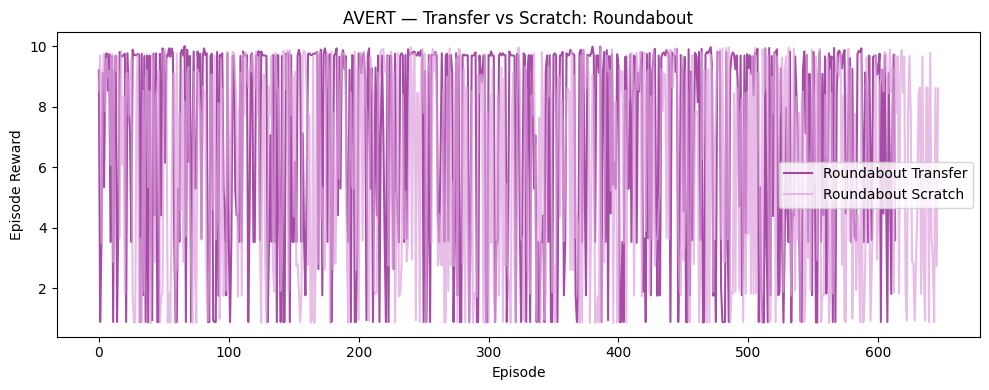

Roundabout last-20 mean — Transfer: 6.74 | Scratch: 4.93


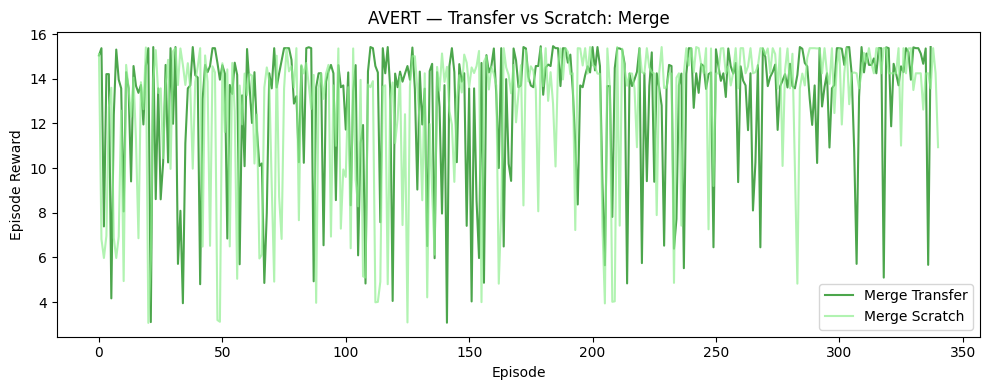

Merge last-20 mean — Transfer: 13.81 | Scratch: 14.05


In [33]:
# Run all plots
plot_rewards({"Stage 1": logger1.rewards, "Stage 2": logger2.rewards, "Stage 3": logger3.rewards})
plot_comparison(logger3.rewards, logger_scratch.rewards)
plot_transfer_vs_scratch(logger_round_trans.rewards, logger_round_scratch.rewards,
                         "Roundabout", "purple", "plum")
plot_transfer_vs_scratch(logger_merge_trans.rewards, logger_merge_scratch.rewards,
                         "Merge", "green", "lightgreen")